In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=1b9bdab73ef1b017856d79e5a703ac0cdbf3709df5f28547de6058a31cc3e30d
  Stored in directory: /root/.cache/pip/wheels/d8/05/68/b3e42de5bbb993864ab67e8f03fd15d7c60b9b21f908f545e5
Successfully built tf-nightly-gpu-2.0-preview


2026-02-28 19:09:55.792591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772305796.005328      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772305796.069514      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix



In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772305813.855639      20 gpu_device.cc:2022] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772305813.859206      20 gpu_device.cc:2022] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (224, 224),  # ResNet50 standard input size
    'batch_size': 32,
    'phase1_epochs': 20,  # Frozen base training
    'phase2_epochs': 15,  # Fine-tuning
    'phase1_learning_rate': 0.001,
    'phase2_learning_rate': 0.0001,
    'num_classes': 4,
    'seed': 42,
    'base_model_name': 'ResNet50'
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


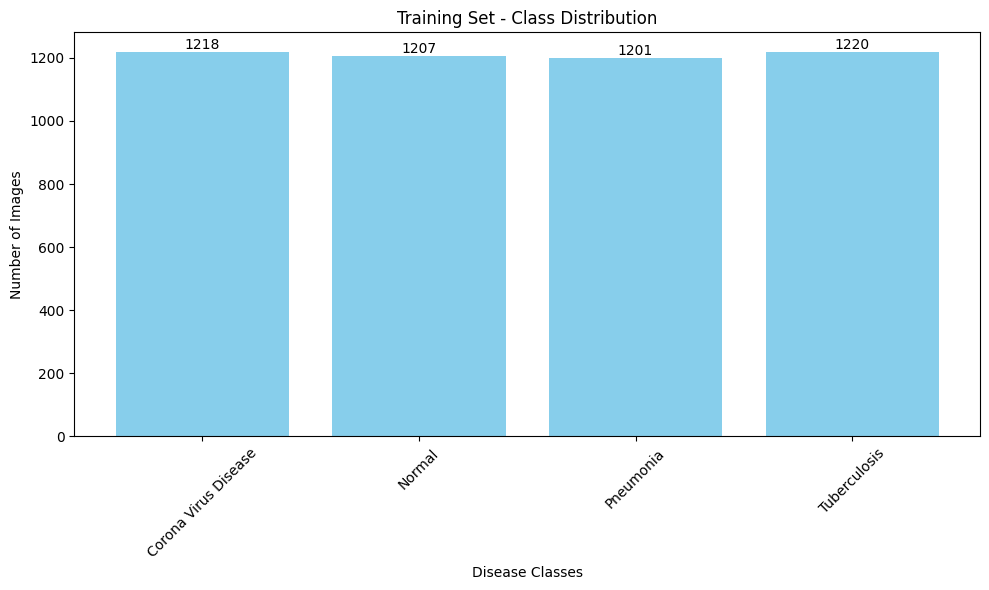


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


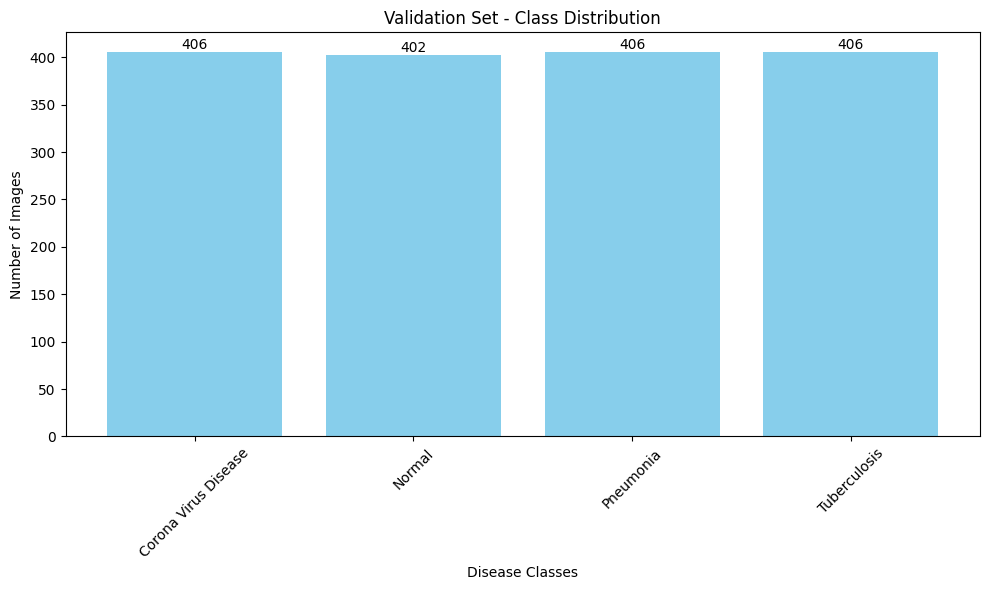


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


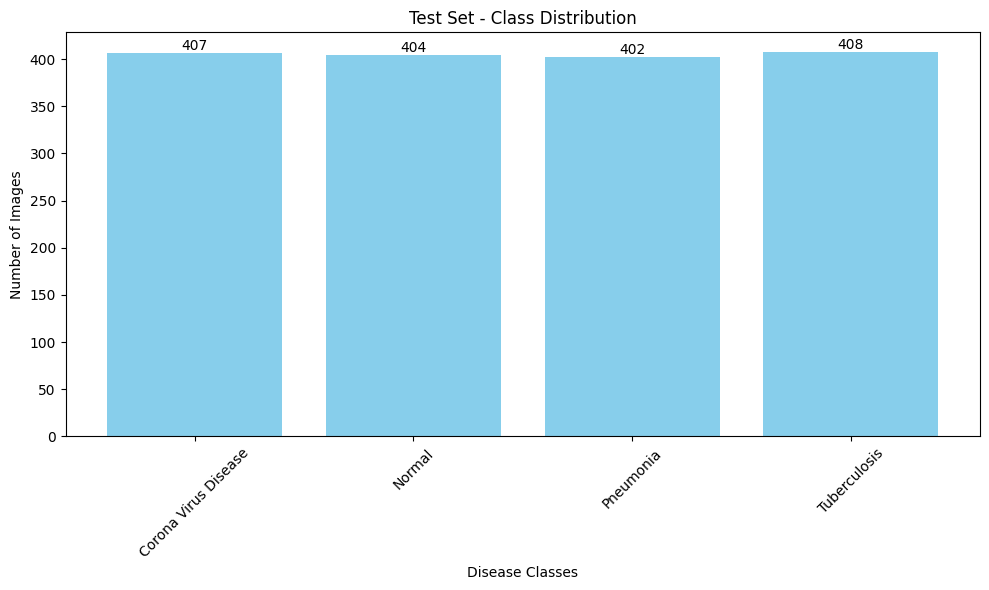

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
def load_datasets():
    """Load training, validation and test datasets"""
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [10]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")

Found 4846 files belonging to 4 classes.


I0000 00:00:1772305818.489554      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772305818.491065      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 152
📁 Validation batches: 51
📁 Test batches: 51


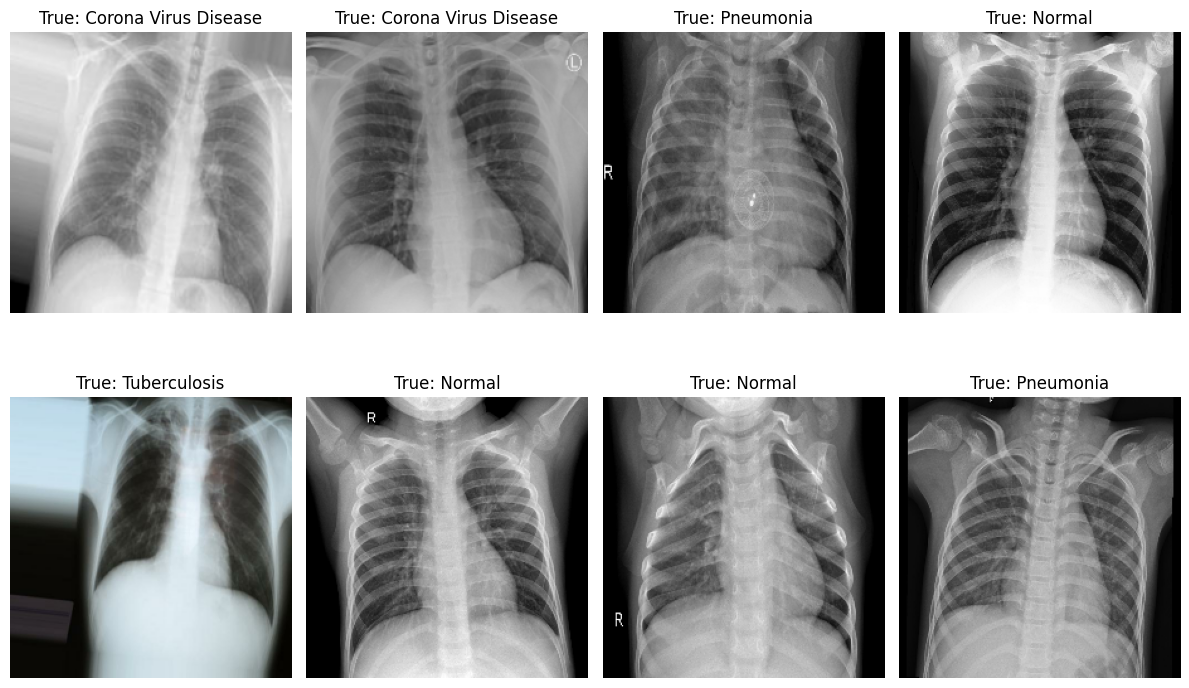

In [11]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [12]:
# -------------------------------
# Model Architecture - Transfer Learning with ResNet50
# -------------------------------
def create_resnet50_model():
    """Create transfer learning model with ResNet50"""
    print(f"\n🛠️ Creating Transfer Learning Model with {CONFIG['base_model_name']}...")
    
    # Create base model with pre-trained weights
    base_model = tf.keras.applications.ResNet50(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,  # Exclude the original classification head
        weights='imagenet',
        pooling='avg'  # GlobalAveragePooling2D
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    print(f"✅ Base model ({CONFIG['base_model_name']}) loaded with ImageNet weights")
    print(f"📊 Base model layers: {len(base_model.layers)}")
    print(f"🔒 Base model trainable: {base_model.trainable}")
    
    # Create custom classifier head
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Apply preprocessing (ResNet50 has built-in preprocessing)
    x = tf.keras.applications.resnet.preprocess_input(inputs)
    
    # Pass through base model
    x = base_model(x, training=False)
    
    # Add custom classifier head
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model

def compile_model(model, learning_rate):
    """Compile the model with optimizer, loss and metrics"""
    print(f"\n⚙️ Compiling Model with learning rate: {learning_rate}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [13]:
def compile_model(model, learning_rate):
    """Compile the model with optimizer, loss and metrics"""
    print(f"\n⚙️ Compiling Model with learning rate: {learning_rate}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [14]:
model, base_model = create_resnet50_model()
model = compile_model(model, CONFIG['phase1_learning_rate'])


🛠️ Creating Transfer Learning Model with ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model (ResNet50) loaded with ImageNet weights
📊 Base model layers: 176
🔒 Base model trainable: False

⚙️ Compiling Model with learning rate: 0.001


In [15]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,804,612 (94.62 MB)

 Trainable params: 1,215,364 (4.64 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [16]:
# -------------------------------
# Training Configuration
# -------------------------------
def get_phase1_callbacks():
    """Get callbacks for phase 1 (frozen base training)"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model from phase 1
        tf.keras.callbacks.ModelCheckpoint(
            'resnet50_phase1_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/resnet50_phase1',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [17]:
phase1_callbacks = get_phase1_callbacks()

In [18]:
phase1_history = model.fit(
        training_set,
        epochs=CONFIG['phase1_epochs'],
        validation_data=validation_set,
        callbacks=phase1_callbacks,
        verbose=1
    )

Epoch 1/20


I0000 00:00:1772305836.978447      79 service.cc:148] XLA service 0x443f0c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772305836.979577      79 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772305836.979598      79 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772305838.965778      79 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1772305846.095450      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7640 - f1_score: 0.7637 - loss: 0.5992 - precision: 0.8021 - recall: 0.7258
Epoch 1: val_accuracy improved from -inf to 0.93210, saving model to resnet50_phase1_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 335ms/step - accuracy: 0.7646 - f1_score: 0.7644 - loss: 0.5977 - precision: 0.8026 - recall: 0.7266 - val_accuracy: 0.9321 - val_f1_score: 0.9325 - val_loss: 0.1847 - val_precision: 0.9343 - val_recall: 0.9302 - learning_rate: 0.0010
Epoch 2/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9175 - f1_score: 0.9176 - loss: 0.2448 - precision: 0.9200 - recall: 0.9119
Epoch 2: val_accuracy improved from 0.93210 to 0.94691, saving model to resnet50_phase1_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.9175 - f1_score: 0.9176 - loss: 0.2447 - precision: 0.9200 - recall: 0.9119 - val_accuracy: 0.9469 - val_f1_score: 0.9468 - val_loss: 0.1555 - val_precision: 0.9480 - val_recall: 0.9451 - le

In [19]:
def get_phase2_callbacks():
    """Get callbacks for phase 2 (fine-tuning)"""
    callbacks = [
        # Early stopping with less patience for fine-tuning
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        ),
        
        # Save best model from phase 2
        tf.keras.callbacks.ModelCheckpoint(
            'resnet50_phase2_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/resnet50_phase2',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [20]:
def setup_fine_tuning(base_model):
    """Setup fine-tuning strategy for ResNet50"""
    print(f"\n🎯 Setting up Fine-tuning Strategy...")
    
    # Unfreeze the base model
    base_model.trainable = True
    
    # ResNet50 has 5 main stages. We'll fine-tune from stage 4 onwards
    # This means we freeze stages 1-3 and fine-tune stages 4-5
    
    # Fine-tune from this layer onwards (stage 4)
    fine_tune_at = None
    for i, layer in enumerate(base_model.layers):
        if 'conv4_block1' in layer.name:
            fine_tune_at = i
            break
    
    if fine_tune_at is None:
        # Fallback: fine-tune last 1/3 of layers
        fine_tune_at = len(base_model.layers) * 2 // 3
    
    print(f"   Fine-tuning from layer {fine_tune_at} ('{base_model.layers[fine_tune_at].name}')")
    
    # Freeze all the layers before the `fine_tune_at` layer
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    # Count trainable vs frozen layers
    frozen_count = sum([not layer.trainable for layer in base_model.layers])
    trainable_count = sum([layer.trainable for layer in base_model.layers])
    
    print(f"   Frozen layers: {frozen_count}")
    print(f"   Trainable layers: {trainable_count}")
    print(f"   Percentage trainable: {trainable_count/len(base_model.layers)*100:.1f}%")
    
    # Show some example layers and their trainability
    print(f"\n   Example layer trainability:")
    for i in range(max(0, fine_tune_at-2), min(len(base_model.layers), fine_tune_at+3)):
        layer = base_model.layers[i]
        status = "TRAINABLE" if layer.trainable else "FROZEN"
        print(f"     Layer {i}: {layer.name} - {status}")
    
    return fine_tune_at

In [21]:
# Setup fine-tuning strategy for ResNet50
fine_tune_at = setup_fine_tuning(base_model)
    
# Recompile with lower learning rate for fine-tuning
model = compile_model(model, CONFIG['phase2_learning_rate'])
    
phase2_callbacks = get_phase2_callbacks()


🎯 Setting up Fine-tuning Strategy...
   Fine-tuning from layer 81 ('conv4_block1_1_conv')
   Frozen layers: 81
   Trainable layers: 95
   Percentage trainable: 54.0%

   Example layer trainability:
     Layer 79: conv3_block4_add - FROZEN
     Layer 80: conv3_block4_out - FROZEN
     Layer 81: conv4_block1_1_conv - TRAINABLE
     Layer 82: conv4_block1_1_bn - TRAINABLE
     Layer 83: conv4_block1_1_relu - TRAINABLE

⚙️ Compiling Model with learning rate: 0.0001


In [22]:
print("🚀 Starting Phase 2 fine-tuning...")
phase2_history = model.fit(
        training_set,
        epochs=CONFIG['phase2_epochs'],
        validation_data=validation_set,
        callbacks=phase2_callbacks,
        verbose=1
    )

🚀 Starting Phase 2 fine-tuning...
Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9297 - f1_score: 0.9296 - loss: 0.2016 - precision: 0.9308 - recall: 0.9289
Epoch 1: val_accuracy improved from -inf to 0.96914, saving model to resnet50_phase2_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 104s 422ms/step - accuracy: 0.9298 - f1_score: 0.9297 - loss: 0.2013 - precision: 0.9309 - recall: 0.9290 - val_accuracy: 0.9691 - val_f1_score: 0.9691 - val_loss: 0.0902 - val_precision: 0.9697 - val_recall: 0.9685 - learning_rate: 1.0000e-04
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9745 - f1_score: 0.9745 - loss: 0.0660 - precision: 0.9746 - recall: 0.9741
Epoch 2: val_accuracy did not improve from 0.96914
152/152 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - accuracy: 0.9745 - f1_score: 0.9745 - loss: 0.0660 - precision: 0.9747 - recall: 0.9741 - val_accuracy: 0.9667 - val_f1_score: 0.9666 - val_loss: 0.1052 - val_precision: 0.9673 - val_recall: 0.9667 - learni

In [23]:
# Save the final model
model.save('resnet50_final_model.h5')
model.save('resnet50_final_model.keras')

In [24]:
with open('resnet50_training_history.pkl', 'wb') as f:
        history_data = {
            'phase1': phase1_history.history,
            'phase2': phase2_history.history,
            'combined': {key: phase1_history.history[key] + phase2_history.history[key] 
                        for key in phase1_history.history.keys()},
            'config': CONFIG,
            'fine_tune_at': fine_tune_at
        }
        pickle.dump(history_data, f)

# Model Evaluation

In [25]:
# -------------------------------
# Training Functions
# -------------------------------
def plot_combined_training_history(phase1_history, phase2_history):
    """Plot combined training history from both phases"""
    print("\n📈 Plotting Combined Training History...")
    
    # Combine histories
    combined_history = {}
    for key in phase1_history.history.keys():
        combined_history[key] = phase1_history.history[key] + phase2_history.history[key]
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Mark phase transition
    phase_transition = len(phase1_history.history['loss'])
    
    # Loss
    axes[0, 0].plot(combined_history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(combined_history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 1].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(combined_history['precision'], label='Training Precision', linewidth=2, color='blue')
    axes[0, 2].plot(combined_history['val_precision'], label='Validation Precision', linewidth=2, color='red')
    axes[0, 2].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 2].set_title('Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(combined_history['recall'], label='Training Recall', linewidth=2, color='blue')
    axes[1, 0].plot(combined_history['val_recall'], label='Validation Recall', linewidth=2, color='red')
    axes[1, 0].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 0].set_title('Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(combined_history['f1_score'], label='Training F1-Score', linewidth=2, color='blue')
    axes[1, 1].plot(combined_history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='red')
    axes[1, 1].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 1].set_title('Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in combined_history:
        axes[1, 2].plot(combined_history['lr'], label='Learning Rate', linewidth=2, color='green')
        axes[1, 2].axvline(x=phase_transition, color='purple', linestyle='--', alpha=0.7, label='Fine-tuning Start')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training History - {CONFIG["base_model_name"]} (Phase 1: Frozen, Phase 2: Fine-tuning)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return combined_history


📈 Plotting Combined Training History...


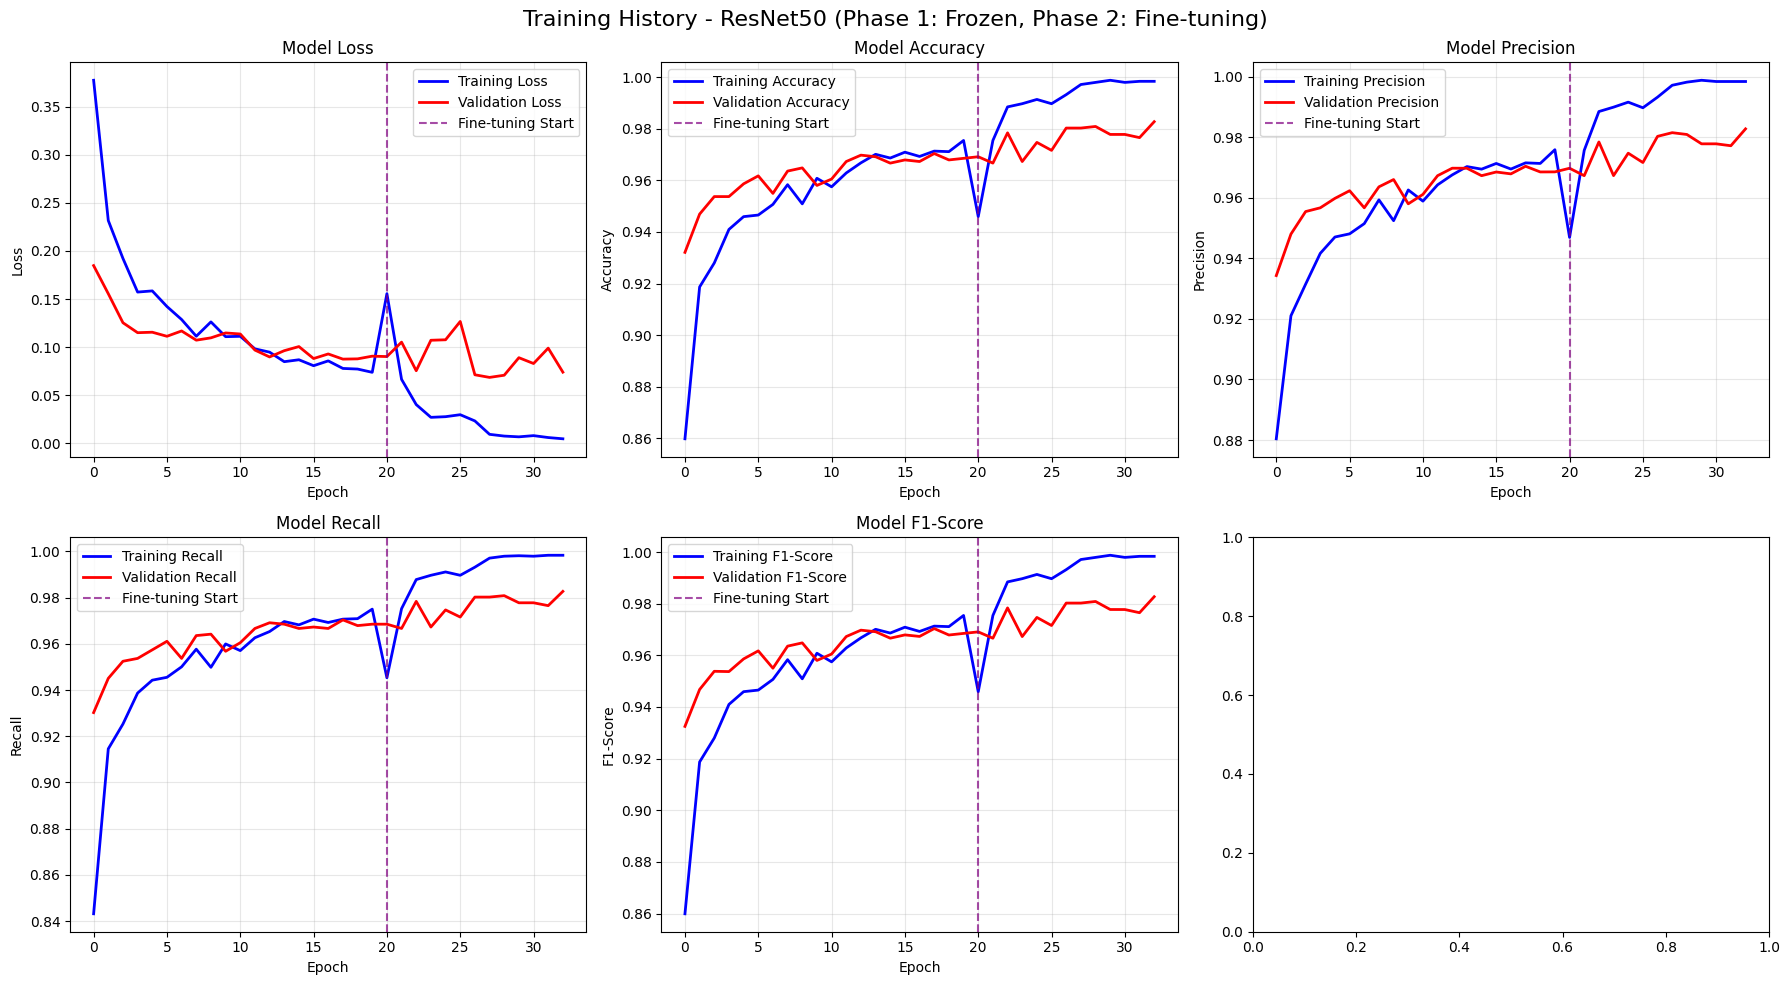

In [26]:
combined_history = plot_combined_training_history(phase1_history, phase2_history)

In [27]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_model(model, test_set, class_names):
    """Comprehensive model evaluation"""
    print("\n🧪 Evaluating Model Performance...")
    
    # Basic evaluation
    print("📊 Running Model Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Predictions...")
    y_true = []
    y_pred = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    return y_true, y_pred, eval_dict


In [28]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()


🧪 Evaluating Model Performance...
📊 Running Model Evaluation...
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step - accuracy: 0.9823 - f1_score: 0.9856 - loss: 0.0664 - precision: 0.9823 - recall: 0.9823

📋 Evaluation Results:
   Loss: 0.0746
   Accuracy: 0.9803
   Precision: 0.9803
   Recall: 0.9803
   F1_score: 0.9803

🔍 Generating Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       1.00      0.99      0.99       407
              Normal       0.95      0.98      0.97       404
           Pneumonia       0.98      0.96      0.97       402
        Tuberculosis       0.99      1.00      1.00       408

            accuracy                           0.98      1621
           macro avg       0.98      0.98      0.98      1621
        weighted avg       0.98      0.98      0.98      1621



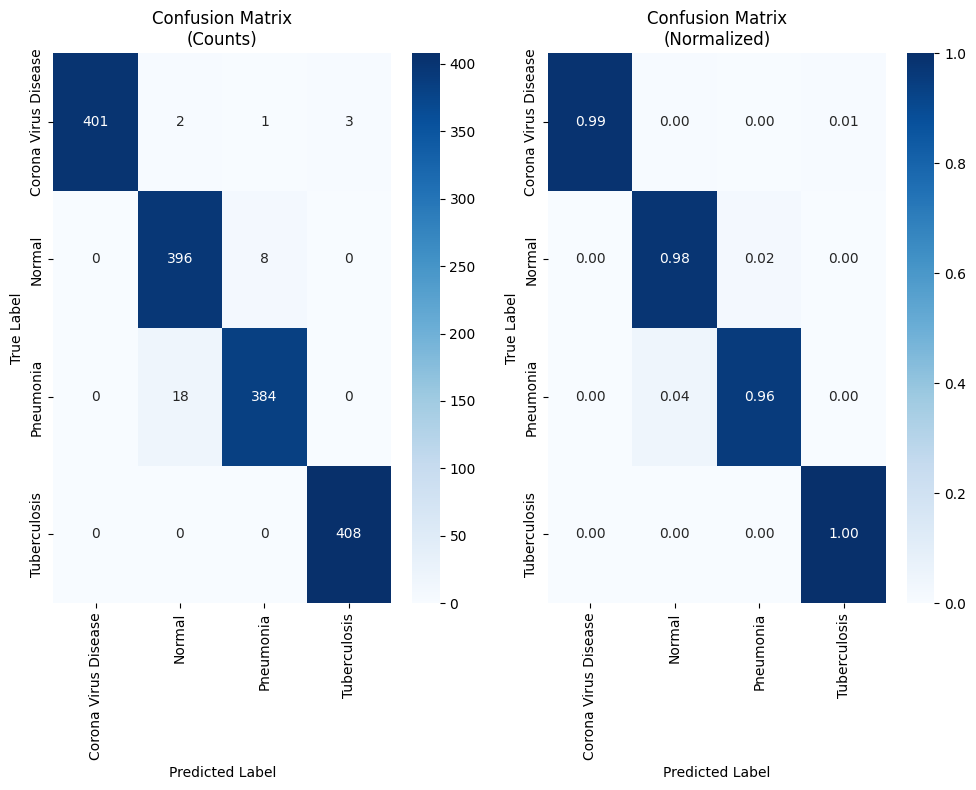

In [29]:
y_true, y_pred, eval_results = evaluate_model(model, test_set, class_names)

In [30]:
print("🎉 Transfer Learning with ResNet50 Completed Successfully!")
print(f"📊 Final Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Final Test F1-Score: {eval_results['f1_score']:.2%}")
    

🎉 Transfer Learning with ResNet50 Completed Successfully!
📊 Final Test Accuracy: 98.03%
📊 Final Test F1-Score: 98.03%


In [31]:
# Display training summary
print(f"\n📈 Training Summary:")
print(f"   Phase 1 (Frozen): {len(phase1_history.history['loss'])} epochs")
print(f"   Phase 2 (Fine-tuned): {len(phase2_history.history['loss'])} epochs")
print(f"   Total Epochs: {len(phase1_history.history['loss']) + len(phase2_history.history['loss'])}")
print(f"   Fine-tuned from: Layer {fine_tune_at} ({base_model.layers[fine_tune_at].name})")


📈 Training Summary:
   Phase 1 (Frozen): 20 epochs
   Phase 2 (Fine-tuned): 13 epochs
   Total Epochs: 33
   Fine-tuned from: Layer 81 (conv4_block1_1_conv)


In [32]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Corona Virus Disease/00030357_000.png"
img = tf.keras.utils.load_img(image_path, target_size=(224,224))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

(1, 224, 224, 3)

In [33]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Model Prediction:  Corona Virus Disease
